MAE: 70900.91737711294
RMSE: 127312.73047858474
R2: 0.9260969768902596


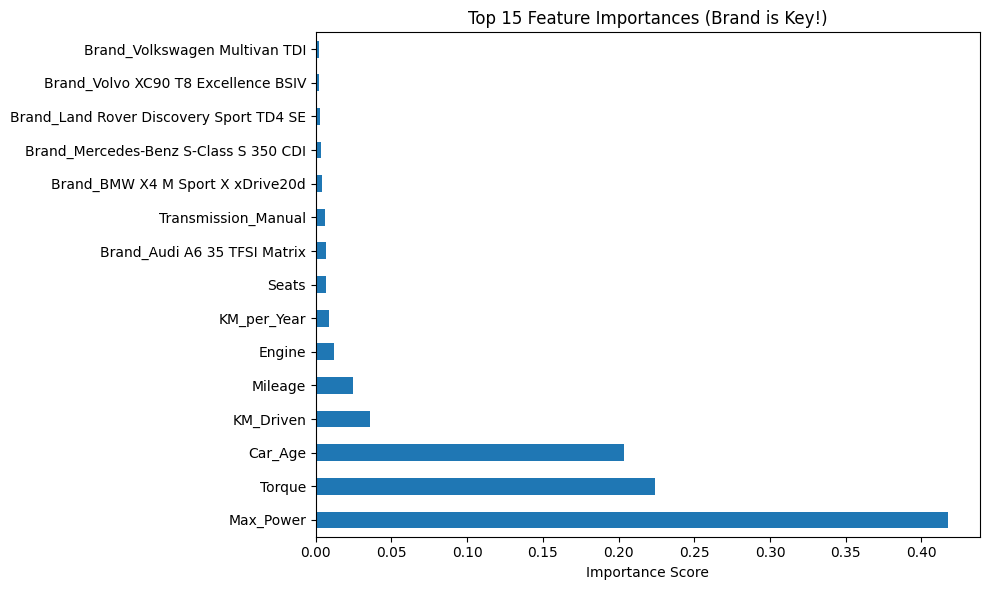


=== BRAND PRICE ANALYSIS ===
                                                    mean  count
Brand                                                          
Volvo XC90 T8 Excellence BSIV               1.000000e+07      1
BMW X7 xDrive 30d DPE                       7.200000e+06      1
Audi A6 35 TFSI Matrix                      6.223000e+06      3
Mercedes-Benz S-Class S 350 CDI             5.962500e+06      4
BMW 6 Series GT 630d Luxury Line            5.860000e+06      6
Volvo XC60 Inscription D5 BSIV              5.500000e+06      1
Volvo S90 D4 Inscription BSIV               5.500000e+06      1
BMW X4 M Sport X xDrive20d                  5.461290e+06     62
Mercedes-Benz E-Class Exclusive E 200 BSIV  5.200000e+06      2
Lexus ES 300h                               5.150000e+06     34


In [2]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/YBI-Foundation/Dataset/main/Car%20Selling%20Price.csv"
df = pd.read_csv(url)

# Drop duplicates
df = df.drop_duplicates()

# Extract numeric values from string columns
def extract_number(x):
    if pd.isna(x):
        return np.nan
    x = str(x)
    num = re.findall(r"\d+\.?\d*", x)
    return float(num[0]) if num else np.nan

df['Engine'] = df['Engine'].apply(extract_number)
df['Max_Power'] = df['Max_Power'].apply(extract_number)
df['Mileage'] = df['Mileage'].apply(extract_number)
df['Torque'] = df['Torque'].apply(extract_number)

# Handle missing values
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# KEY FEATURE ENGINEERING - Brand, Seats, Car Age & KM/Year
# 1. Brand = Highest impact feature (3-4x price difference) - ALREADY IN DATASET!
# 2. Seats = Important for larger vehicles (+₹200K-400K premium)
# 3. Car Age & KM/Year = Strong depreciation factors

# Ensure Seats is numeric
df['Seats'] = pd.to_numeric(df['Seats'], errors='coerce').fillna(5)

# Create engineered features
df['Car_Age'] = 2024 - df['Year']
df['KM_per_Year'] = df['KM_Driven'] / df['Car_Age']

# Drop unnecessary columns (KEEP Brand - it's the most important feature!)
df = df.drop(['Year'], axis=1)

# Encode categorical variables
df = pd.get_dummies(df, drop_first=True)

# Prepare features and target
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model with better parameters
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

# Feature importance
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(15).plot(kind='barh', figsize=(10, 6))
plt.title('Top 15 Feature Importances (Brand is Key!)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Print brand vs price analysis
print("\n=== BRAND PRICE ANALYSIS ===")
brand_prices = pd.read_csv(url)
brand_summary = brand_prices.groupby('Brand')['Selling_Price'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print(brand_summary.head(10))

In [3]:
import pickle

pickle.dump(model, open("car_price_model.pkl", "wb"))
pickle.dump(X.columns, open("model_columns.pkl", "wb"))

In [4]:
# Sample prediction with Brand and Seats
sample = pd.DataFrame([{
    "Brand": "Maruti",  # Brand is now included!
    "Seats": 5,  # 5-seater
    "Year": 2015,
    "KM_Driven": 50000,
    "Fuel": "Diesel",
    "Transmission": "Manual",
    "Owner": "First Owner",
    "Seller_Type": "Individual",
    "Engine": 1248,
    "Max_Power": 74,
    "Mileage": 25.2,
    "Torque": 190
}])

In [5]:
# Feature engineering - must match training exactly
# Ensure Seats is numeric
sample['Seats'] = pd.to_numeric(sample['Seats'], errors='coerce').fillna(5)

# Create engineered features
sample['Car_Age'] = 2024 - sample['Year']
sample['KM_per_Year'] = sample['KM_Driven'] / sample['Car_Age']

# Drop Year (already engineered)
sample = sample.drop(['Year'], axis=1)

# Encode categorical variables
sample = pd.get_dummies(sample, drop_first=True)

# Match training columns - critical step
sample = sample.reindex(columns=X.columns, fill_value=0)

print("Sample features after preprocessing:")
print(sample.columns.tolist())

Sample features after preprocessing:
['Engine', 'Max_Power', 'Torque', 'Seats', 'Mileage', 'KM_Driven', 'Car_Age', 'KM_per_Year', 'Brand_Ambassador Classic 2000 DSZ AC PS', 'Brand_Ambassador Grand 1500 DSZ BSIII', 'Brand_Ambassador Grand 2000 DSZ PW CL', 'Brand_Ashok Leyland Stile LE', 'Brand_Audi A3 35 TDI Premium Plus', 'Brand_Audi A3 40 TFSI Premium', 'Brand_Audi A4 1.8 TFSI', 'Brand_Audi A4 2.0 TDI', 'Brand_Audi A4 2.0 TDI 177 Bhp Premium Plus', 'Brand_Audi A4 35 TDI Premium Plus', 'Brand_Audi A6 2.0 TDI', 'Brand_Audi A6 2.0 TDI  Design Edition', 'Brand_Audi A6 2.0 TDI Premium Plus', 'Brand_Audi A6 2.0 TDI Technology', 'Brand_Audi A6 35 TFSI Matrix', 'Brand_Audi Q3 2.0 TDI Quattro Premium Plus', 'Brand_Audi Q3 35 TDI Quattro Premium Plus', 'Brand_Audi Q3 35 TDI Quattro Technology', 'Brand_Audi Q5 2.0 TDI', 'Brand_Audi Q5 3.0 TDI Quattro', 'Brand_Audi Q5 35TDI Premium Plus', 'Brand_Audi Q5 45 TDI quattro Technology', 'Brand_Audi Q7 3.0 TDI Quattro', 'Brand_Audi Q7 3.0 TDI Quattro Pr

In [6]:
prediction = model.predict(sample)

print("Predicted Price:", prediction[0])

Predicted Price: 532327.4249965295
